# Data setup and EDA

Czech bank data from the PKDD'99 Financial ("Berka") dataset - 8 tables
covering 4,500 accounts, their owners, loans, cards, and just over a
million individual transactions (1993-1998). There's no fraud/AML label
anywhere in this data - it's ordinary retail banking activity - so the
goal here is behavioral profiling: build account-level features good
enough to (a) flag accounts whose transaction behavior looks unusual
without any label at all, and (b) predict which loans went bad from
account behavior, which does have a real, independent outcome to predict.

In [1]:
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = 'data'
BASE_URL = 'https://raw.githubusercontent.com/jlacko/berka-dataset/master/'
TABLES = ['account', 'card', 'client', 'disp', 'district', 'loan', 'order', 'trans']

os.makedirs(DATA_DIR, exist_ok = True)
for name in TABLES:
    path = os.path.join(DATA_DIR, f'{name}.asc')
    if not os.path.exists(path):
        urllib.request.urlretrieve(BASE_URL + f'{name}.asc', path)

{name: os.path.getsize(os.path.join(DATA_DIR, f'{name}.asc')) for name in TABLES}

{'account': 155356,
 'card': 31588,
 'client': 94820,
 'disp': 129716,
 'district': 6574,
 'loan': 27037,
 'order': 273800,
 'trans': 69406578}

In [2]:
account = pd.read_csv('data/account.asc', sep = ';')
card = pd.read_csv('data/card.asc', sep = ';')
client = pd.read_csv('data/client.asc', sep = ';')
disp = pd.read_csv('data/disp.asc', sep = ';')
district = pd.read_csv('data/district.asc', sep = ';')
loan = pd.read_csv('data/loan.asc', sep = ';')
order = pd.read_csv('data/order.asc', sep = ';')
trans = pd.read_csv('data/trans.asc', sep = ';', low_memory = False)

# district columns are coded A1-A16 in the raw file - the data dictionary names them
district.columns = [
    'district_id', 'district_name', 'region', 'inhabitants',
    'municip_lt499', 'municip_500_1999', 'municip_2000_9999', 'municip_gt10000',
    'n_cities', 'urban_ratio', 'avg_salary', 'unemployment_95', 'unemployment_96',
    'entrepreneur_ratio', 'crimes_95', 'crimes_96',
]

account.shape, card.shape, client.shape, disp.shape, district.shape, loan.shape, order.shape, trans.shape

((4500, 4),
 (892, 4),
 (5369, 3),
 (5369, 4),
 (77, 16),
 (682, 7),
 (6471, 6),
 (1056320, 10))

4,500 accounts, 682 loans (so most accounts never take a loan), 892 cards, and 1,056,320 transactions - checking the shapes against the dataset's well-known published stats as a sanity check that the download is complete and correctly parsed.

In [3]:
loan['status'].value_counts()

status
C    403
A    203
D     45
B     31
Name: count, dtype: int64

Loan status codes: `A` = contract finished, no problems; `B` = contract finished, loan **not** paid; `C` = running contract, OK so far; `D` = running contract, client in debt. `B`/`D` (76 of 682 loans, 11.1%) are the closest thing this dataset has to a real "bad outcome" label - a genuine, independent target, unlike synthesizing a label from clustering the same features you'd then predict it from.

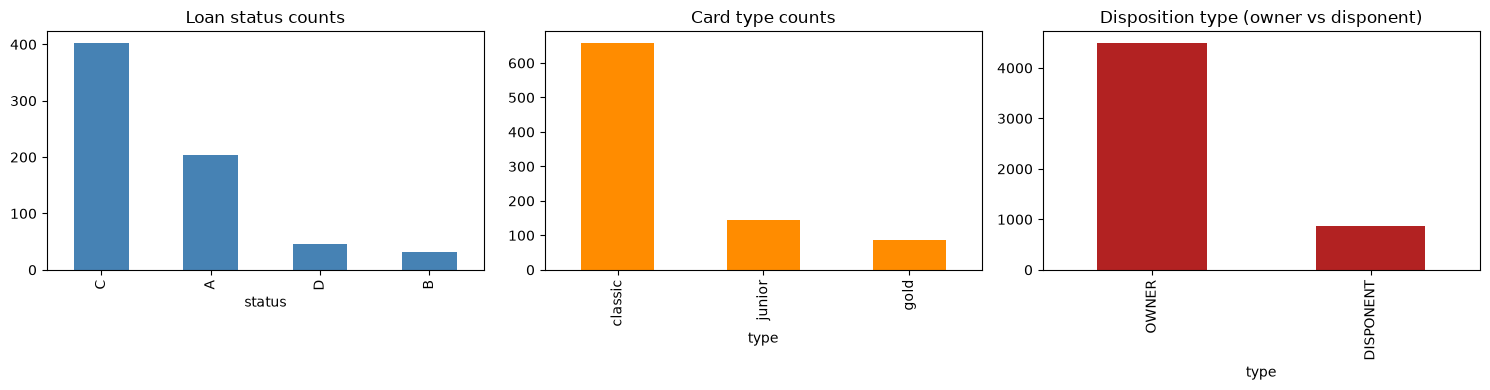

In [4]:
fig, axes = plt.subplots(1, 3, figsize = (15, 4))

loan['status'].value_counts().plot.bar(ax = axes[0], color = 'steelblue')
axes[0].set_title('Loan status counts')

card['type'].value_counts().plot.bar(ax = axes[1], color = 'darkorange')
axes[1].set_title('Card type counts')

disp['type'].value_counts().plot.bar(ax = axes[2], color = 'firebrick')
axes[2].set_title('Disposition type (owner vs disponent)')

plt.tight_layout()
plt.savefig('outputs/account_overview.png', dpi = 120)
plt.show()

In [5]:
trans['type'].value_counts()

type
VYDAJ     634571
PRIJEM    405083
VYBER      16666
Name: count, dtype: int64

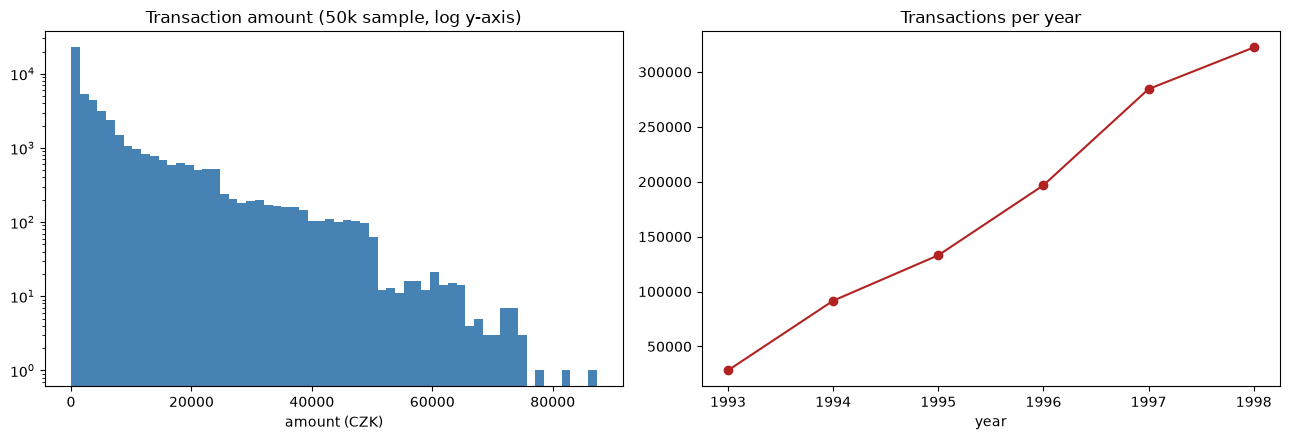

In [6]:
fig, axes = plt.subplots(1, 2, figsize = (13, 4.5))

trans_sample = trans.sample(50_000, random_state = 42)
axes[0].hist(trans_sample['amount'], bins = 60, color = 'steelblue')
axes[0].set_yscale('log')
axes[0].set_title('Transaction amount (50k sample, log y-axis)')
axes[0].set_xlabel('amount (CZK)')

trans['year'] = (trans['date'] // 10000) + 1900
trans.groupby('year').size().plot(ax = axes[1], marker = 'o', color = 'firebrick')
axes[1].set_title('Transactions per year')

plt.tight_layout()
plt.savefig('outputs/transaction_overview.png', dpi = 120)
plt.show()

District demographics - joined in for context, not yet used as a feature. Average salary and unemployment vary a lot by region, which is worth knowing before treating "unusual spending" as universal across the whole country.

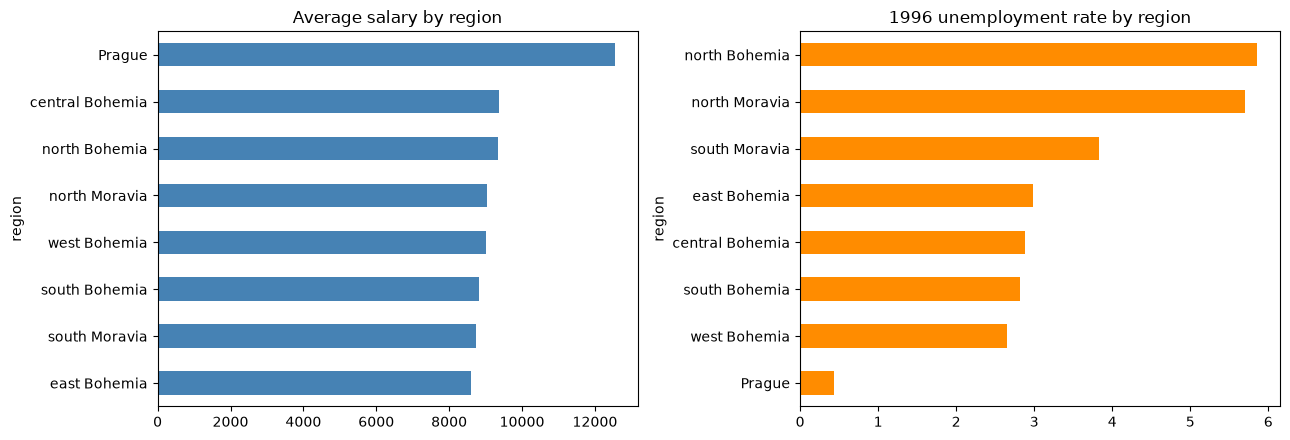

In [7]:
fig, axes = plt.subplots(1, 2, figsize = (13, 4.5))

district.groupby('region')['avg_salary'].mean().sort_values().plot.barh(ax = axes[0], color = 'steelblue')
axes[0].set_title('Average salary by region')

district.groupby('region')['unemployment_96'].mean().sort_values().plot.barh(ax = axes[1], color = 'darkorange')
axes[1].set_title('1996 unemployment rate by region')

plt.tight_layout()
plt.savefig('outputs/district_overview.png', dpi = 120)
plt.show()

One thing the original version of this project got wrong: chaining several `inner` merges (account + loan + card + transactions) restricts the analysis to only accounts that happen to have all of those simultaneously - a small, biased slice. Every join below is a `left` join from the full account list, so every one of the 4,500 accounts stays in the picture whether or not it has a loan or a card.

In [8]:
account_full = (
    account
    .merge(district, on = 'district_id', how = 'left')
    .merge(disp[disp['type'] == 'OWNER'][['account_id', 'client_id']], on = 'account_id', how = 'left')
    .merge(client[['client_id', 'birth_number', 'district_id']].rename(
        columns = {'district_id': 'client_district_id'}), on = 'client_id', how = 'left')
)

has_loan = loan.groupby('account_id').size().gt(0)
has_card = card.merge(disp[['disp_id', 'account_id']], on = 'disp_id', how = 'left').groupby('account_id').size().gt(0)

account_full['has_loan'] = account_full['account_id'].map(has_loan).fillna(False)
account_full['has_card'] = account_full['account_id'].map(has_card).fillna(False)

account_full[['has_loan', 'has_card']].mean()

has_loan    0.151556
has_card    0.198222
dtype: object

In [9]:
import json
os.makedirs('outputs', exist_ok = True)

summary = {
    'n_accounts': int(len(account)),
    'n_loans': int(len(loan)),
    'n_cards': int(len(card)),
    'n_transactions': int(len(trans)),
    'loan_status_counts': loan['status'].value_counts().to_dict(),
    'pct_accounts_with_loan': float(account_full['has_loan'].mean()),
    'pct_accounts_with_card': float(account_full['has_card'].mean()),
}
with open('outputs/data_summary.json', 'w') as f:
    json.dump(summary, f, indent = 2)

summary

{'n_accounts': 4500,
 'n_loans': 682,
 'n_cards': 892,
 'n_transactions': 1056320,
 'loan_status_counts': {'C': 403, 'A': 203, 'D': 45, 'B': 31},
 'pct_accounts_with_loan': 0.15155555555555555,
 'pct_accounts_with_card': 0.19822222222222222}